In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)

In [175]:
dados='CARAMELO.csv'
df=pd.read_csv(dados , encoding='utf-8', sep=';')

df.head(10) 
#10 primeiras linhas


,ID Venda,Loja,ID Loja,Estado Loja,Cidade Loja,Nome Cliente,ID Cliente,Sexo,Idade,Estado Cliente,Cidade Cliente,ID Produto,Categoria Produto,Marca,Data da Compra,Data da Entrega,Metodo de Pagamento,Produto,Valor de Venda
0,1,Melo,49,BA,Salvador,Lucas Silveira,35727,Masculino,24,BA,Vitória da Conquista,946,Eletrônicos,Lenovo,2024-12-20,2024-12-30,Pix,Drone,"8979,56"
1,10,Mendonça Machado Ltda.,7,SP,Sorocaba,Isabella Campos,2188,Feminino,41,MG,Uberlândia,112,Eletrônicos,Apple,2023-11-22,2023-11-28,Dinheiro,Celular,"112146,00"
2,1000,Cunha Mendes S.A.,97,BA,Camaçari,Marcela Barbosa,2293,Feminino,47,SP,Sorocaba,283,Alimentos,Del Valle,2023-08-25,2023-08-27,Dinheiro,Suco,"37,08"
3,100001,Nunes,77,MG,Contagem,Ravy Cunha,38559,Feminino,59,RJ,Petrópolis,805,Eletrônicos,Dell,2024-08-03,2024-08-04,Dinheiro,Notebook,"13455,14"
4,100007,Cunha Mendes S.A.,97,BA,Camaçari,Sra. Ana Cecília Pinto,19274,Masculino,27,SP,São Paulo,362,Alimentos,Coca-Cola,2023-02-28,2023-03-08,Pix,Refrigerante,"17,33"
5,100010,Melo,49,BA,Salvador,Sr. Rhavi Siqueira,237,Feminino,55,BA,Salvador,183,Alimentos,Barilla,2023-04-13,2023-04-14,Pix,Macarrão,"20,33"
6,100011,Machado,40,RS,Caxias do Sul,Isaque Pimenta,25565,Masculino,67,RJ,Rio de Janeiro,283,Alimentos,Del Valle,2025-11-15,2025-11-25,Cartão,Suco,"29,87"
7,100012,Moreira,53,RJ,Rio de Janeiro,Sr. Gustavo Cavalcanti,27717,Masculino,62,BA,Salvador,286,Livros,Amazon,2025-07-07,2025-07-09,Cartão,A Revolução dos Bichos,"157,62"
8,100014,Moreira,53,RJ,Rio de Janeiro,Dr. Bruno Nunes,37283,Feminino,59,SP,Santos,615,Eletrônicos,Sony,2025-06-08,2025-06-10,Pix,Monitor,"15428,64"
9,100015,Teixeira,49,RS,Novo Hamburgo,Henry Gabriel Vasconcelos,36864,Masculino,60,RJ,Rio de Janeiro,926,Alimentos,Nestlé,2023-06-10,2023-06-12,Cartão,Chocolate,"25,67"


# Limpeza


In [176]:
df.isnull().sum()
#Quantidade de valores nulos por coluna


ID Venda               0
Loja                   0
ID Loja                0
Estado Loja            0
Cidade Loja            0
Nome Cliente           0
ID Cliente             0
Sexo                   0
Idade                  0
Estado Cliente         0
Cidade Cliente         0
ID Produto             0
Categoria Produto      0
Marca                  0
Data da Compra         0
Data da Entrega        0
Metodo de Pagamento    0
Produto                0
Valor de Venda         0
dtype: int64

In [177]:
df.info()
# Data de compra e entrega está como string e valor de venda também


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   ID Venda             150000 non-null  int64
 1   Loja                 150000 non-null  str  
 2   ID Loja              150000 non-null  int64
 3   Estado Loja          150000 non-null  str  
 4   Cidade Loja          150000 non-null  str  
 5   Nome Cliente         150000 non-null  str  
 6   ID Cliente           150000 non-null  int64
 7   Sexo                 150000 non-null  str  
 8   Idade                150000 non-null  int64
 9   Estado Cliente       150000 non-null  str  
 10  Cidade Cliente       150000 non-null  str  
 11  ID Produto           150000 non-null  int64
 12  Categoria Produto    150000 non-null  str  
 13  Marca                150000 non-null  str  
 14  Data da Compra       150000 non-null  str  
 15  Data da Entrega      150000 non-null  str  
 16  Metodo de Pag

In [178]:
df['Data da Compra'] = pd.to_datetime(df['Data da Compra'])
df['Data da Entrega'] = pd.to_datetime(df['Data da Entrega'])
df['Valor de Venda'] = pd.to_numeric(
    df['Valor de Venda']
        .astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
    errors='coerce'
)
#pd.to_datetime tranforma as colunas em datas
#pd.to_numeric converte para número , o primeiro replace remove os pontos e o segundo substitui vírgula por ponto
#erros='coerse' substitui valores caso existissem por 'NaN' 


df

,ID Venda,Loja,ID Loja,Estado Loja,Cidade Loja,Nome Cliente,ID Cliente,Sexo,Idade,Estado Cliente,Cidade Cliente,ID Produto,Categoria Produto,Marca,Data da Compra,Data da Entrega,Metodo de Pagamento,Produto,Valor de Venda
0,1,Melo,49,BA,Salvador,Lucas Silveira,35727,Masculino,24,BA,Vitória da Conquista,946,Eletrônicos,Lenovo,2024-12-20,2024-12-30,Pix,Drone,8979.56
1,10,Mendonça Machado Ltda.,7,SP,Sorocaba,Isabella Campos,2188,Feminino,41,MG,Uberlândia,112,Eletrônicos,Apple,2023-11-22,2023-11-28,Dinheiro,Celular,112146.00
2,1000,Cunha Mendes S.A.,97,BA,Camaçari,Marcela Barbosa,2293,Feminino,47,SP,Sorocaba,283,Alimentos,Del Valle,2023-08-25,2023-08-27,Dinheiro,Suco,37.08
3,100001,Nunes,77,MG,Contagem,Ravy Cunha,38559,Feminino,59,RJ,Petrópolis,805,Eletrônicos,Dell,2024-08-03,2024-08-04,Dinheiro,Notebook,13455.14
4,100007,Cunha Mendes S.A.,97,BA,Camaçari,Sra. Ana Cecília Pinto,19274,Masculino,27,SP,São Paulo,362,Alimentos,Coca-Cola,2023-02-28,2023-03-08,Pix,Refrigerante,17.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,99992,Barbosa,96,RS,Pelotas,Caleb da Mota,223,Masculino,63,BA,Salvador,623,Alimentos,Pilão,2024-11-11,2024-11-15,Cartão,Café,33.27
149996,99994,Aparecida da Conceição e Filhos,15,RJ,Campos dos Goytacazes,Eduardo Cavalcanti,8975,Masculino,39,BA,Salvador,253,Alimentos,Vigorelli,2025-01-11,2025-01-13,Pix,Feijão,15.50
149997,99997,Moreira,53,RJ,Rio de Janeiro,Pedro Miguel Mendes,36587,Masculino,43,RS,Pelotas,535,Alimentos,Camil,2023-09-09,2023-09-15,Dinheiro,Arroz,27.83
149998,99998,Andrade,94,SP,Santos,Ana Luiza Porto,3938,Feminino,36,BA,Feira de Santana,183,Alimentos,Barilla,2025-01-01,2025-01-02,Pix,Macarrão,61.16


# KPI Principais

In [179]:
faturamento_total = df['Valor de Venda'].sum()
ticket_medio = df['Valor de Venda'].mean()
quantidade_vendas = df.shape[0]

print(f'Faturamento Total: R$ {faturamento_total:,.2f}')
print(f'Ticket Médio: R$ {ticket_medio:,.2f}')
print(f'Quantidade de Vendas: {quantidade_vendas}')

Faturamento Total: R$ 495,598,261.12
Ticket Médio: R$ 3,303.99
Quantidade de Vendas: 150000


# Vendas por Loja

In [180]:
vendas_por_loja = (
    df.groupby('Loja')['Valor de Venda']
    .sum()
    .reset_index()
    .sort_values(by='Valor de Venda', ascending=False)
)
vendas_por_loja

,Loja,Valor de Venda
10,Mendonça Machado Ltda.,73919670.56
7,Gomes,39371215.05
6,Fernandes,37107099.24
0,Andrade,36868599.90
3,Cunha,36133723.77
12,Moura - ME,35509673.51
11,Moreira,26847044.73
17,Sousa,18350601.22
15,Sampaio Viana Ltda.,18017479.95
19,Vargas,17769332.66


# Vendas por Categoria

In [181]:
vendas_por_categoria = (
    df.groupby('Categoria Produto')['Valor de Venda']
    .sum()
    .reset_index()
    .sort_values(by='Valor de Venda', ascending=False)
)
vendas_por_categoria


,Categoria Produto,Valor de Venda
1,Eletrônicos,398284376.66
3,Móveis,78552157.79
4,Roupas,14495598.61
0,Alimentos,2892560.74
2,Livros,1373567.32


# Filtro Eletrônicos

In [182]:
df_eletronicos = df[df['Categoria Produto'] == 'Eletrônicos']

produtos_eletronicos = (
    df_eletronicos.groupby('Produto')['Valor de Venda']
    .sum()
    .reset_index()
    .sort_values(by='Valor de Venda', ascending=False)
)
produtos_eletronicos

,Produto,Valor de Venda
10,Teclado,52449847.31
0,Celular,51362657.26
3,Fone de Ouvido,49368227.23
6,Notebook,34446750.39
5,Mouse,33362050.01
9,Tablet,33088129.29
1,Console de Videogame,31663357.68
4,Monitor,30621309.99
8,TV,28401147.89
7,Smartwatch,27830646.35


In [183]:
df_eletronicos = df[df['Categoria Produto'] == 'Eletrônicos']

produtos_eletronicos = (
    df_eletronicos.groupby('Produto')['Valor de Venda']
    .sum()
    .reset_index()
    .sort_values(by='Valor de Venda', ascending=False)
)


# Análise Estatística

In [184]:
valores_loja = np.array(vendas_por_loja['Valor de Venda'])

q1 = np.percentile(valores_loja, 25)
q2 = np.percentile(valores_loja, 50)
q3 = np.percentile(valores_loja, 75)

media = np.mean(valores_loja)
mediana = np.median(valores_loja)

iqr = q3 - q1

distancia=(media-mediana)/mediana

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print(f'Q1: {q1:.2f}')
print(f'Mediana: {q2:.2f}')
print(f'Q3: {q3:.2f}')
print(f'Média: {media:.2f}')
print(f'Valor da distancia é: {distancia*100:.2f}')

Q1: 15538622.59
Mediana: 17489484.62
Q3: 35665686.08
Média: 24779913.06
Valor da distancia é: 41.68


In [185]:
valores_categoria = np.array(vendas_por_categoria['Valor de Venda'])

q1 = np.percentile(valores_categoria, 25)
q2 = np.percentile(valores_categoria, 50)
q3 = np.percentile(valores_categoria, 75)

media = np.mean(valores_categoria)
mediana = np.median(valores_categoria)

iqr = q3 - q1

distancia=(media-mediana)/mediana

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

print(f'Q1: {q1:.2f}')
print(f'Mediana: {q2:.2f}')
print(f'Q3: {q3:.2f}')
print(f'Média: {media:.2f}')
print(f'Valor da distancia é: {distancia*100:.2f}')

Q1: 2892560.74
Mediana: 14495598.61
Q3: 78552157.79
Média: 99119652.22
Valor da distancia é: 583.79


# Outliers

In [186]:
outliers_categorias= vendas_por_categoria.loc[vendas_por_categoria['Valor de Venda']>=limite_superior]
outliers_categorias= outliers_categorias.sort_values(by='Valor de Venda',ascending=False)
outliers_categorias
#Categoria Eletônicos é um outlier

,Categoria Produto,Valor de Venda
1,Eletrônicos,398284376.66


In [187]:
outliers_loja= vendas_por_loja.loc[vendas_por_loja['Valor de Venda']>=limite_superior]
outliers_loja= outliers_loja.sort_values(by='Valor de Venda',ascending=False)
outliers_loja


,Loja,Valor de Venda


# Gráfico Geral

C:\Users\Henry\AppData\Local\Temp\ipykernel_25256\4254570970.py:46: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Henry\Documents\Senac-Dados-Henry-\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


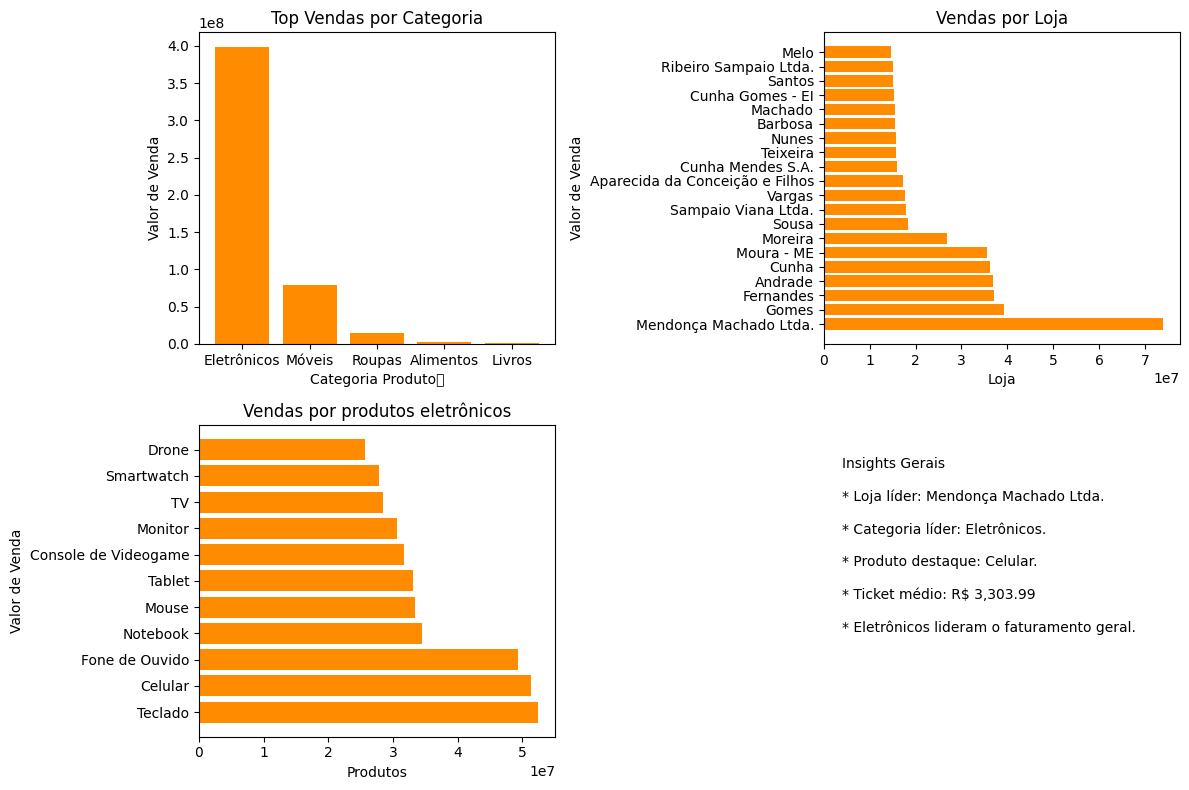

In [188]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].bar(vendas_por_categoria['Categoria Produto'], vendas_por_categoria['Valor de Venda'], color='#FF8C00')
axs[0, 0].set_title('Top Vendas por Categoria')   # Título do gráfico
axs[0, 0].set_xlabel('Categoria Produto	')    # Rótulo do eixo X
axs[0, 0].set_ylabel('Valor de Venda')    # Rótulo do eixo Y


axs[0, 1].barh(vendas_por_loja['Loja'], vendas_por_loja['Valor de Venda'], color='#FF8C00')
axs[0, 1].set_title('Vendas por Loja')   # Título do gráfico
axs[0, 1].set_xlabel('Loja')    # Rótulo do eixo X
axs[0, 1].set_ylabel('Valor de Venda')    # Rótulo do eixo Y


axs[1, 0].barh(produtos_eletronicos['Produto'], produtos_eletronicos['Valor de Venda'], color='#FF8C00')
axs[1, 0].set_title('Vendas por produtos eletrônicos')   # Título do gráfico
axs[1, 0].set_xlabel('Produtos')    # Rótulo do eixo X
axs[1, 0].set_ylabel('Valor de Venda')    # Rótulo do eixo Y

# Remove os eixos do último gráfico vazio
axs[1,1].axis('off')

# Texto explicativo
texto_info = f"""
Insights Gerais

* Loja líder: Mendonça Machado Ltda.

* Categoria líder: Eletrônicos.

* Produto destaque: Celular.

* Ticket médio: R$ {ticket_medio:,.2f}

* Eletrônicos lideram o faturamento geral.
"""
# Adiciona o texto no espaço vazio
axs[1,1].text(
    0.05, 0.95,
    texto_info,
    fontsize=10,
    verticalalignment='top'
)


# Ajusta os espaços entre os gráficos para evitar sobreposição
plt.tight_layout()

# Exibe todos os gráficos juntos
plt.show()

# Análise Temporal

In [189]:
# criar colunas auxiliares de tempo
df['Ano'] = df['Data da Compra'].dt.year
df['Mes'] = df['Data da Compra'].dt.month
df['Dia'] = df['Data da Compra'].dt.day
df['AnoMes'] = df['Data da Compra'].dt.to_period('M')

In [190]:
# todas as vendas por dia
vendas_dia = df.groupby('Data da Compra')['Valor de Venda'].sum().reset_index()
vendas_dia = vendas_dia.sort_values(by='Data da Compra')
vendas_dia.head()



,Data da Compra,Valor de Venda
0,2023-01-01,388556.30
1,2023-01-02,611079.42
2,2023-01-03,387582.65
3,2023-01-04,410081.59
4,2023-01-05,445047.74


In [191]:
# vendas por mes
vendas_mes = df.groupby('AnoMes')['Valor de Venda'].sum().reset_index()
vendas_mes['AnoMes'] = vendas_mes['AnoMes'].astype(str)
vendas_mes.head()

,AnoMes,Valor de Venda
0,2023-01,12435896.33
1,2023-02,10370262.66
2,2023-03,12496228.25
3,2023-04,12440955.87
4,2023-05,13898417.93


In [192]:
# tendência de vendas por ano, janeiro fraco, dezembro forte
vendas_mes['Crescimento %'] = vendas_mes['Valor de Venda'].pct_change() * 100
vendas_mes

,AnoMes,Valor de Venda,Crescimento %
0,2023-01,12435896.33,NaN
1,2023-02,10370262.66,-16.61
2,2023-03,12496228.25,20.50
3,2023-04,12440955.87,-0.44
4,2023-05,13898417.93,11.72
5,2023-06,13163330.10,-5.29
6,2023-07,17443677.31,32.52
7,2023-08,13974123.04,-19.89
8,2023-09,12061215.13,-13.69
9,2023-10,12401021.89,2.82


# Gráfico Temporal

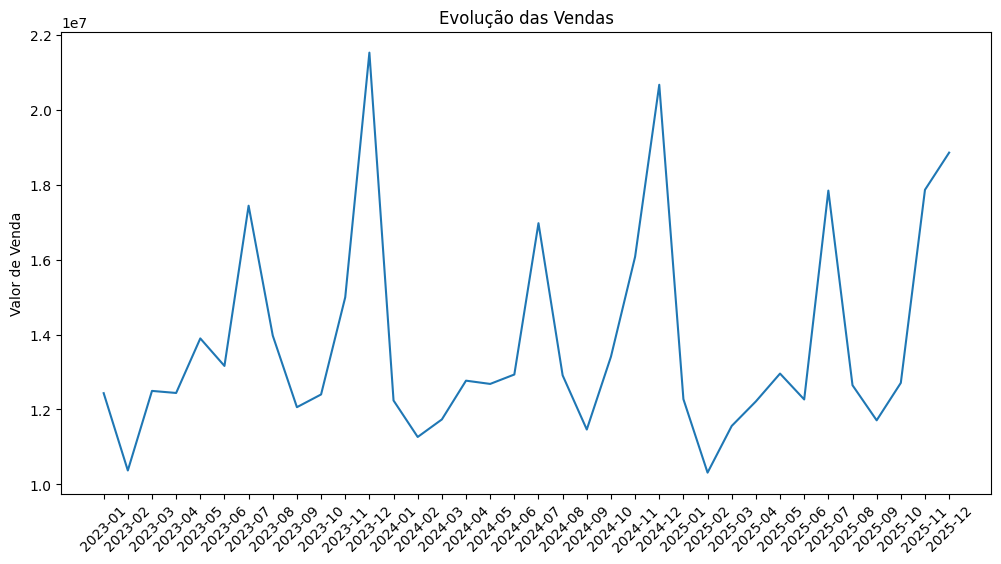

In [193]:
plt.figure(figsize=(12,6))
plt.plot(vendas_mes['AnoMes'], vendas_mes['Valor de Venda'])

plt.title('Evolução das Vendas')
plt.xticks(rotation=45)
plt.ylabel('Valor de Venda')
plt.show()

In [194]:
df.to_csv(
    "caramelo_base_tratada.csv",
    index=False,
    encoding="utf-8",
    sep=","
)

print("Arquivo 'caramelo_base_tratada.csv' gerado com sucesso!")

Arquivo 'caramelo_base_tratada.csv' gerado com sucesso!


# Conclusão Final

In [195]:

"""
A análise dos dados permitiu identificar padrões importantes de vendas, 
como as categorias com maior faturamento, desempenho das lojas e comportamento temporal.

Foi possível observar o ticket médio das vendas, distribuição dos valores 
e possíveis variações entre categorias e lojas.

Além disso, a análise estatística ajudou a compreender a dispersão dos dados 
e identificar possíveis comportamentos fora do padrão.

Este projeto demonstrou a aplicação de técnicas de limpeza, tratamento, 
visualização e análise exploratória de dados utilizando Python.

Com base na análise realizada, foi possível identificar quais segmentos 
geram maior faturamento e como as vendas se comportam ao longo do tempo.

Os resultados ajudam na tomada de decisão, permitindo identificar oportunidades 
de melhoria, categorias de maior destaque e possíveis tendências de consumo.

Este projeto reforça a importância da análise de dados para gerar insights 
e apoiar decisões de negócio.
"""

'\nA análise dos dados permitiu identificar padrões importantes de vendas, \ncomo as categorias com maior faturamento, desempenho das lojas e comportamento temporal.\n\nFoi possível observar o ticket médio das vendas, distribuição dos valores \ne possíveis variações entre categorias e lojas.\n\nAlém disso, a análise estatística ajudou a compreender a dispersão dos dados \ne identificar possíveis comportamentos fora do padrão.\n\nEste projeto demonstrou a aplicação de técnicas de limpeza, tratamento, \nvisualização e análise exploratória de dados utilizando Python.\n\nCom base na análise realizada, foi possível identificar quais segmentos \ngeram maior faturamento e como as vendas se comportam ao longo do tempo.\n\nOs resultados ajudam na tomada de decisão, permitindo identificar oportunidades \nde melhoria, categorias de maior destaque e possíveis tendências de consumo.\n\nEste projeto reforça a importância da análise de dados para gerar insights \ne apoiar decisões de negócio.\n'